In [200]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

%matplotlib inline

In [201]:
df = pd.read_csv('Life_Expectancy_Data.csv')
df.shape

(2938, 22)

In [202]:
df.dtypes

Country                                str
Year                                 int64
Status                                 str
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [203]:
df.dtypes[df.isna().sum()>0]

Life expectancy                    float64
Adult Mortality                    float64
Alcohol                            float64
Hepatitis B                        float64
 BMI                               float64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [204]:
df.columns = df.columns.str.replace(' ', '')
df.columns


Index(['Country', 'Year', 'Status', 'Lifeexpectancy', 'AdultMortality',
       'infantdeaths', 'Alcohol', 'percentageexpenditure', 'HepatitisB',
       'Measles', 'BMI', 'under-fivedeaths', 'Polio', 'Totalexpenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness1-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='str')

In [205]:
from sklearn.model_selection import train_test_split

df = df.dropna(subset=['Lifeexpectancy'])
X = df.drop('Lifeexpectancy', axis=1)
y = df['Lifeexpectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

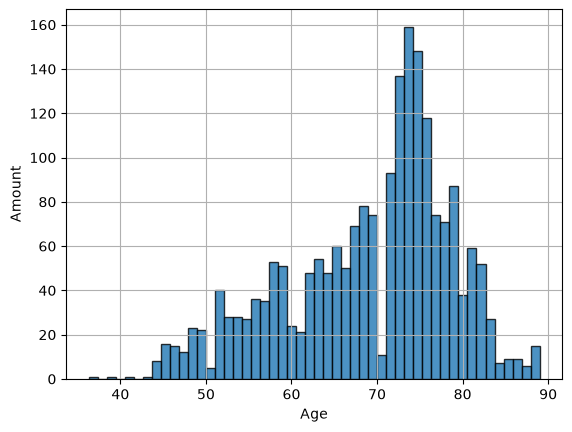

In [206]:
y_train.hist(bins=50, edgecolor='black', alpha=0.8)
plt.xlabel('Age')
plt.ylabel('Amount')
plt.show()

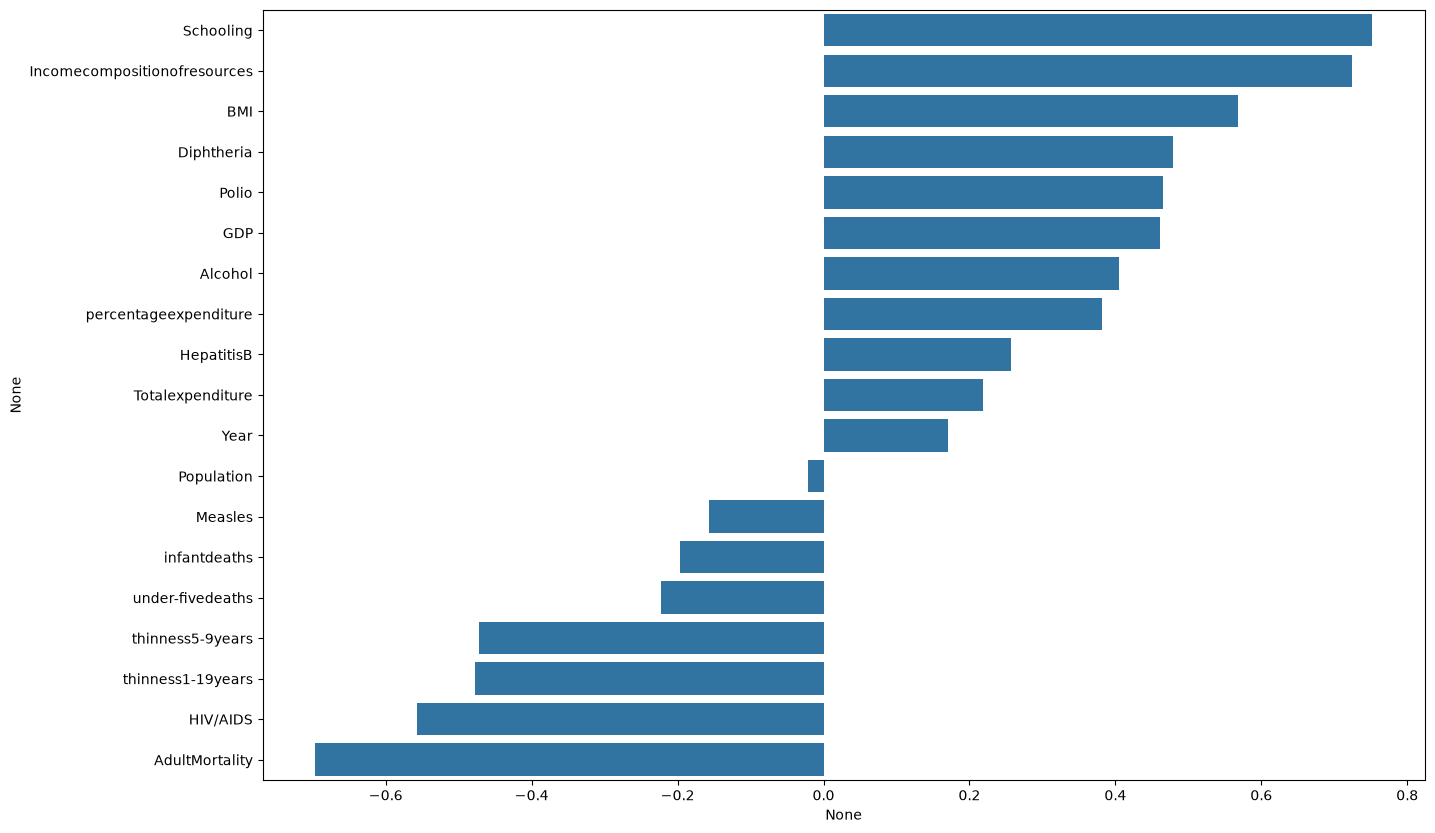

In [207]:
numeric_data = X_train.select_dtypes([np.number])
numeric_data_mean = numeric_data.mean()
numeric_features = numeric_data.columns

X_train = X_train.fillna(numeric_data_mean)
X_test = X_test.fillna(numeric_data_mean)

corr = df[numeric_features].corrwith(df['Lifeexpectancy']).sort_values(ascending=False)
plot = sns.barplot(y=corr.index, x=corr)
plot.figure.set_size_inches(15,10)

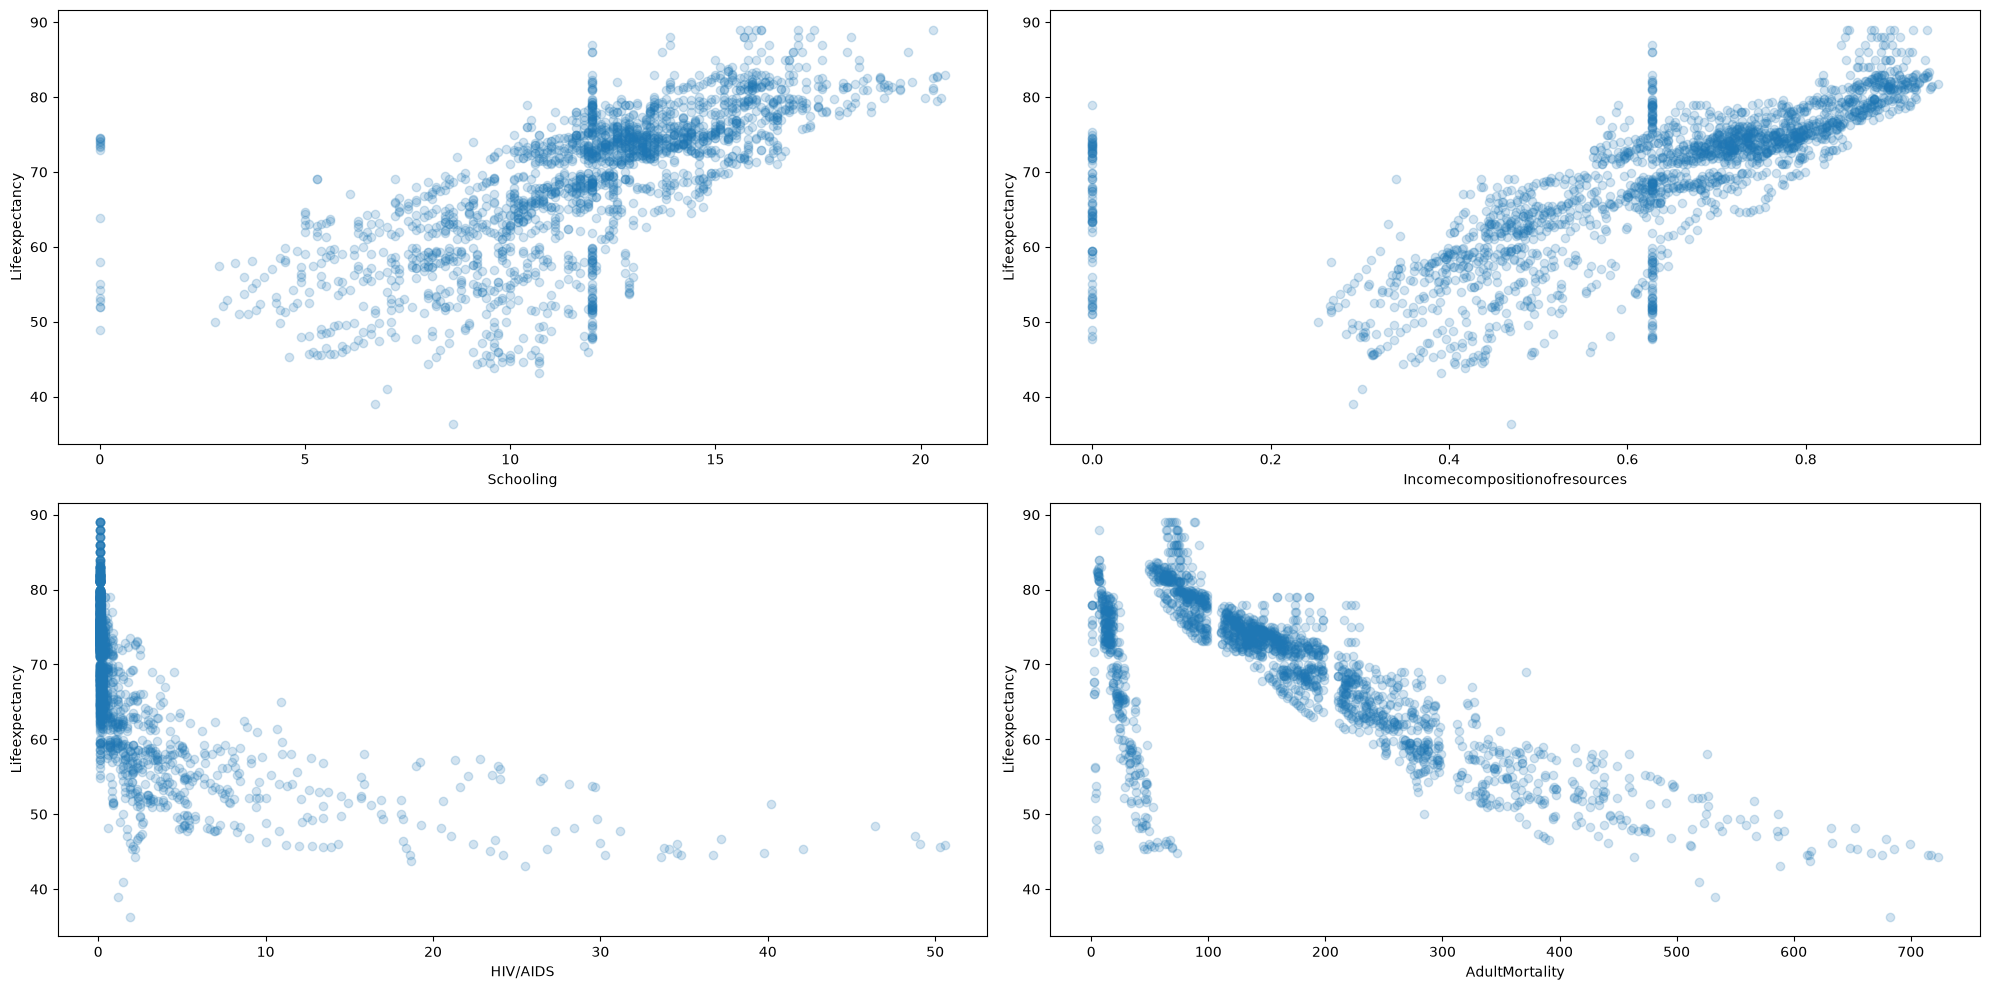

In [208]:
fig, axs = plt.subplots(figsize=(20,10), nrows=2 ,ncols=2)
for i, feature in enumerate(['Schooling','Incomecompositionofresources', 'HIV/AIDS', 'AdultMortality']):
    axs[i//2, i%2].scatter(X_train[feature], y_train, alpha=0.2)
    axs[i//2, i%2].set_xlabel(feature)
    axs[i//2, i%2].set_ylabel('Lifeexpectancy')
plt.tight_layout()

In [209]:
categorical = list(X_train.dtypes[X_train.dtypes.isin(["str","object"])].index)
X_train[categorical] = X_train[categorical].fillna("NotGiven")
X_test[categorical] = X_test[categorical].fillna("NotGiven")

In [210]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, root_mean_squared_error

model_ridge = Ridge()
model_lasso = Lasso()

model_ridge.fit(X_train[numeric_features], y_train)
y_pred_ridge = model_ridge.predict(X_train[numeric_features])

model_lasso.fit(X_train[numeric_features], y_train)
y_pred_lasso = model_lasso.predict(X_train[numeric_features])

print('Ridge. Train RMSE = %.4f' % root_mean_squared_error(y_train,y_pred_ridge))
print('Ridge. Train R^2 = %.4f' % r2_score(y_train, y_pred_ridge))

print('Lasso. Train RMSE = %.4f' % root_mean_squared_error(y_train,y_pred_lasso))
print('Lasso. Train R^2 = %.4f' % r2_score(y_train, y_pred_lasso))

Ridge. Train RMSE = 4.0593
Ridge. Train R^2 = 0.8237
Lasso. Train RMSE = 4.1640
Lasso. Train R^2 = 0.8145


/home/artemka/projects/github/ml-models/venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.772160391053688e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/artemka/projects/github/ml-models/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.762412e+04, tolerance: 1.915e+01
  model = cd_fast.enet_coordinate_descent(


In [211]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train[numeric_features])
X_test_scaled = scaler.transform(X_test[numeric_features])


Best alpha = 0.2069


Text(0, 0.5, 'CV score')

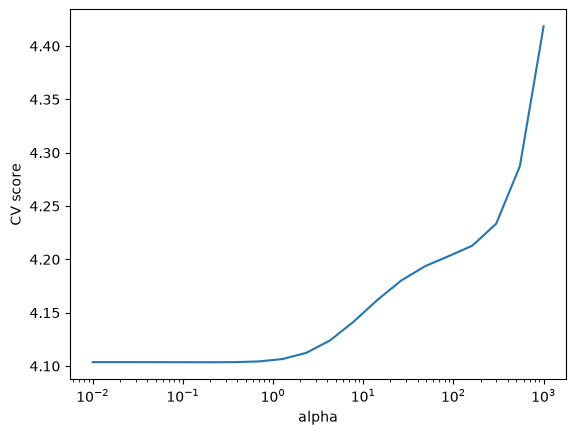

In [212]:
from sklearn.model_selection import GridSearchCV

alphas = np.logspace(-2, 3, 20)
searcher = GridSearchCV(Ridge(), [{"alpha": alphas}], scoring="neg_root_mean_squared_error", cv=10)
searcher.fit(X_train_scaled, y_train)

best_alpha = searcher.best_params_["alpha"]
print("Best alpha = %.4f" % best_alpha)

plt.plot(alphas, -searcher.cv_results_["mean_test_score"])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV score")

In [213]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), categorical),
    ('scaling', StandardScaler(), numeric_features)
])

pipeline_ridge = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

pipeline_lasso= Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Lasso(best_alpha))
])

model_ridge = pipeline_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)

model_lasso = pipeline_lasso.fit(X_train, y_train)
y_pred_lasso = model_lasso.predict(X_test)

print("Ridge. Test RMSE = %.4f" % root_mean_squared_error(y_test, y_pred_ridge))
print("Ridge. Test R^2 = %.4f" % r2_score(y_test, y_pred_ridge))

print("Lasso. Test RMSE = %.4f" % root_mean_squared_error(y_test, y_pred_lasso))
print("Lasso. Test R^2 = %.4f" % r2_score(y_test, y_pred_lasso))

Ridge. Test RMSE = 4.0722
Ridge. Test R^2 = 0.8028
Lasso. Test RMSE = 4.1287
Lasso. Test R^2 = 0.7973
